# Reddit Analysis

### Import Libraries

In [27]:
# Import libraries
import networkx as nx
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community import asyn_lpa_communities
import pandas as pd
import matplotlib.pyplot as plt
import math
from collections import Counter

### Create Network Graph

In [28]:
# Convert csv as dataframe
df = pd.read_csv(
    "data/reddit_links.tsv",
    sep="\t",
    dtype={
        "SOURCE_SUBREDDIT": "string",
        "TARGET_SUBREDDIT": "string",
        "POST_ID": "string",
        "TIMESTAMP": "string",
        "PROPERTIES": "string",
        "LINK_SENTIMENT": "Int64",
    },
    engine="python" 
)

# Keep only wanted rows and non-empty columns in dataframe
df = df[["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT", "LINK_SENTIMENT", "POST_ID", "TIMESTAMP"]]
df = df.dropna(subset=["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"])
df["SOURCE_SUBREDDIT"] = df["SOURCE_SUBREDDIT"].astype(str)
df["TARGET_SUBREDDIT"] = df["TARGET_SUBREDDIT"].astype(str)
df["LINK_SENTIMENT"] = df["LINK_SENTIMENT"].fillna(0).astype(int)

# Create empty multi-directed graph (parallel edges allowed)
G = nx.MultiDiGraph()

# Fill in graph object
for src, tgt, sent, pid, ts in df[["SOURCE_SUBREDDIT","TARGET_SUBREDDIT","LINK_SENTIMENT","POST_ID","TIMESTAMP"]].itertuples(index=False, name=None):
    G.add_edge(src, tgt, LINK_SENTIMENT=int(sent), POST_ID=pid, TIMESTAMP=ts)

# Display number of nodes and edges
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges()) 

Nodes: 35776
Edges: 286561


In [29]:
# Compress parallel edges into weighted edge
Gw = nx.DiGraph()
for u, v in G.edges():
    if Gw.has_edge(u, v):
        Gw[u][v]["weight"] += 1
    else:
        Gw.add_edge(u, v, weight=1)

print("Nodes:", Gw.number_of_nodes())
print("Unique/weighted edges:", Gw.number_of_edges())

Nodes: 35776
Unique/weighted edges: 137821


### Create CSV for Gephi

In [30]:
# Aggregate parallel edges into a single weighted directed edge
edges_df = df.groupby(["SOURCE_SUBREDDIT", "TARGET_SUBREDDIT"], as_index=False).agg(Weight=("POST_ID", "size"), SentimentSum=("LINK_SENTIMENT", "sum"), SentimentMean=("LINK_SENTIMENT", "mean"))

# Rename for Gephi
edges_df = edges_df.rename(columns={"SOURCE_SUBREDDIT": "Source", "TARGET_SUBREDDIT": "Target"})

# Add edge type
edges_df["Type"] = "Directed"

# Reorder columns
edges_df = edges_df[["Source", "Target", "Type", "Weight", "SentimentSum", "SentimentMean"]]

# Save dataframe as csv
edges_df.to_csv("data/reddit_edges.csv", index=False)
print(f"Saved reddit_edges.csv with {len(edges_df)} edges")

Saved reddit_edges.csv with 137821 edges


### Centrality

In [31]:
# Degree centrality unweighted (incoming + outgoing)
deg = nx.degree_centrality(G)

# Betweenness centrality weighted (approximated)
bet = nx.betweenness_centrality(Gw, k=200, normalized=True, seed=42) 

# Eigenvector centrality weighted (approximated)
eig = nx.eigenvector_centrality(Gw, max_iter=2000, tol=1e-6, weight="weight")

top_deg = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:10]
top_bet = sorted(bet.items(), key=lambda x: x[1], reverse=True)[:10]
top_eig = sorted(eig.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Degree Centrality:")
for node, val in top_deg:
    print(node, val)

print("\nTop 10 Betweeness Centrality:")
for node, val in top_bet:
    print(node, val) 

print("\nTop 10 Eigenvector Centrality:")
for node, val in top_eig:
    print(node, val)

Top 10 Degree Centrality:
askreddit 0.2422641509433962
subredditdrama 0.15983228511530398
iama 0.13626834381551362
writingprompts 0.11731656184486372
leagueoflegends 0.09112508735150245
outoftheloop 0.07793151642208246
pics 0.07779175401816911
circlebroke 0.07080363382250174
videos 0.06848357791754017
conspiracy 0.06711390635918937

Top 10 Betweeness Centrality:
subredditdrama 0.04599236880706868
askreddit 0.04579900412493938
iama 0.041245554401250266
outoftheloop 0.02609285789384965
bitcoin 0.02046929302301262
writingprompts 0.01362003296131759
gaming 0.013368050756388234
leagueoflegends 0.011984914363366805
legaladvice 0.011390705370430115
explainlikeimfive 0.01087466826335725

Top 10 Eigenvector Centrality:
buildapc 0.4653175704540207
buildapcforme 0.4426005701812471
pcmasterrace 0.40111935161590184
techsupport 0.36957329288171076
buildapcsales 0.279446627807376
windows10 0.18279943832155157
askreddit 0.13377213480926395
nvidia 0.12562906048466532
buildmeapc 0.11833878864007127
vide

In [32]:
n = len(deg)
top_k = math.ceil(0.10 * n)

# Top 10% by degree
top_deg_nodes = {
    node for node, _ in
    sorted(deg.items(),
           key=lambda x: x[1],
           reverse=True)[:top_k]
}

# Top 10% by betweenness
top_bet_nodes = {
    node for node, _ in
    sorted(bet.items(),
           key=lambda x: x[1],
           reverse=True)[:top_k]
}

# Intersection of degree and betweenness
overlap = top_deg_nodes & top_bet_nodes

print("Total nodes:", n)
print("Top 10% node count:", top_k)
print("Overlap count:", len(overlap))
print(f"Overlap percent: {len(overlap)/top_k * 100:.3f}%")

Total nodes: 35776
Top 10% node count: 3578
Overlap count: 2328
Overlap percent: 65.064%


### Community Detection

In [33]:
# Convert weighted graph to undirected
Gu = Gw.to_undirected()

print("Undirected Nodes:", Gu.number_of_nodes())
print("Undirected Edges:", Gu.number_of_edges())

Undirected Nodes: 35776
Undirected Edges: 124330


In [34]:
# Calculate Louvain comunity
louvain_comms = louvain_communities(Gu, weight="weight", resolution=1.0, seed=42)

print("Louvain communities:", len(louvain_comms))
print("Top 5 sizes:", sorted([len(c) for c in louvain_comms], reverse=True)[:5])

Louvain communities: 551
Top 5 sizes: [5341, 3709, 2963, 2239, 1588]


In [35]:
# Calculate LPA community
lpa_comms = list(asyn_lpa_communities(G, weight="weight", seed=42))

print("LPA communities:", len(lpa_comms))
print("Top 5 sizes:", sorted([len(c) for c in lpa_comms], reverse=True)[:5])

LPA communities: 8289
Top 5 sizes: [15114, 425, 362, 262, 250]


### Degree Distribution

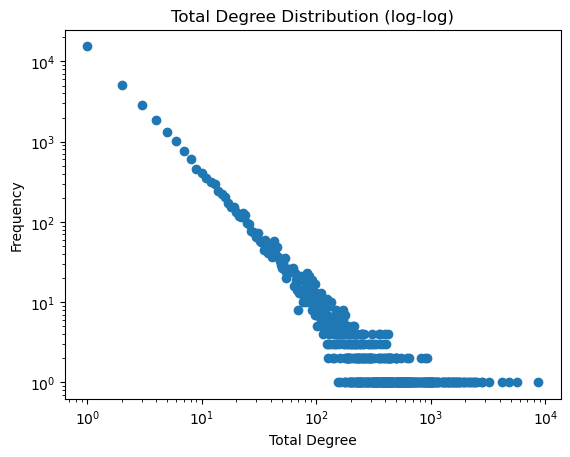

In [36]:
# Frequency of total degrees (in + out)
deg = [d for _, d in G.degree()]
deg_freq = Counter(deg)

# Sort degrees
tot_x = sorted(deg_freq.keys())  
tot_y = [deg_freq[k] for k in tot_x]

plt.figure()
plt.loglog(tot_x, tot_y, marker="o", linestyle="None")
plt.xlabel("Total Degree")
plt.ylabel("Frequency")
plt.title("Total Degree Distribution (log-log)")
plt.show()

### Diameter and Average Shortest Path

In [37]:
num_components = nx.number_strongly_connected_components(Gw)
largest_scc = max(nx.strongly_connected_components(Gw), key=len)
Gscc = Gw.subgraph(largest_scc).copy()

diam = nx.diameter(Gscc)
avg_len = nx.average_shortest_path_length(Gscc)

print("SCCs of Gw:", num_components)
print("Diameter (directed, on largest SCC):", diam)
print("Average shortest path (directed, on largest SCC):", avg_len)
print("Nodes in SCC:", Gscc.number_of_nodes())

SCCs of Gw: 24071
Diameter (directed, on largest SCC): 12
Average shortest path (directed, on largest SCC): 4.071349814095001
Nodes in SCC: 11564
